# BFS × UCS: qual é o melhor caminho de ônibus?

**Versão resumida para apresentação (~10 minutos).** A análise completa, com experimentos de escala, validação e quadro teórico, está no notebook [`ucs_vs_bfs_transporte.ipynb`](ucs_vs_bfs_transporte.ipynb).

> ⚠️ Os bairros são de **João Pessoa (PB)**, mas **as linhas, os tempos e as tarifas são fictícios**.

**Roteiro**
1. O problema
2. Os dois algoritmos
3. Três percursos
4. Comparação dos resultados
5. Conclusões

## 1. O problema

Queremos ir de uma parada a outra usando ônibus, trem ou caminhada. Representamos a rede como um **grafo**:

- cada **parada** é um nó;
- cada **trecho** que dá para fazer num único embarque é uma aresta, com **tempo** (min) e **tarifa** (R\$).

**Pergunta:** qual é a rota **mais rápida**?

In [1]:
from collections import deque        # fila FIFO: a fronteira da BFS
from dataclasses import dataclass    # agrupa o resultado de cada busca
import heapq                         # fila de prioridade: a fronteira da UCS
import itertools                     # contador de desempate da heap

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx                # usado SÓ para desenhar o grafo
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

# Uma cor (e uma forma) para cada algoritmo, iguais em todas as figuras
COR_BFS, COR_UCS = "#2a78d6", "#eb6834"
TINTA, TINTA_SUAVE = "#0b0b0b", "#52514e"

In [2]:
# (parada A, parada B, tempo em min, tarifa em R$, modo, linha): grafo não-direcionado
ARESTAS = [
    ("UFPB", "Castelo Branco", 5, 0.00, "a pé", "caminhada"),
    ("UFPB", "Lagoa", 25, 5.00, "ônibus", "L101"),
    ("UFPB", "Bancários", 12, 5.00, "ônibus", "L201"),
    ("Castelo Branco", "Torre", 15, 5.00, "ônibus", "L102"),
    ("Castelo Branco", "Tambaú", 40, 5.00, "ônibus", "L510"),
    ("Torre", "Tambaú", 12, 5.00, "ônibus", "L103"),
    ("Torre", "Lagoa", 10, 5.00, "ônibus", "L102"),
    ("Bancários", "Mangabeira", 10, 5.00, "ônibus", "L201"),
    ("Bancários", "Cabo Branco", 20, 5.00, "ônibus", "L202"),
    ("Mangabeira", "Valentina", 12, 5.00, "ônibus", "L301"),
    ("Valentina", "Lagoa", 45, 5.00, "ônibus", "L302"),
    ("Cabo Branco", "Tambaú", 15, 0.00, "a pé", "caminhada"),
    ("Tambaú", "Manaíra", 8, 5.00, "ônibus", "L104"),
    ("Manaíra", "Bessa", 10, 5.00, "ônibus", "L104"),
    ("Bessa", "Cabedelo", 20, 5.00, "ônibus", "L105"),
    ("Lagoa", "Tambaú", 25, 5.00, "ônibus", "L106"),
    ("Lagoa", "Manaíra", 30, 5.00, "ônibus", "L107"),
    ("Lagoa", "Rodoviária", 8, 0.00, "a pé", "caminhada"),
    ("Lagoa", "Cruz das Armas", 15, 5.00, "ônibus", "L401"),
    ("Rodoviária", "Estação Ferroviária", 5, 0.00, "a pé", "caminhada"),
    ("Estação Ferroviária", "Bayeux", 12, 0.50, "trem", "Trem"),
    ("Estação Ferroviária", "Cabedelo", 45, 0.50, "trem", "Trem"),
    ("Cruz das Armas", "Bayeux", 15, 5.00, "ônibus", "L402"),
]

# Lista de adjacência: parada -> [(vizinho, {tempo, tarifa, modo, linha}), ...]
grafo = {}
for a, b, tempo, tarifa, modo, linha in ARESTAS:
    atributos = {"tempo": tempo, "tarifa": tarifa, "modo": modo, "linha": linha}
    grafo.setdefault(a, []).append((b, atributos))   # ida
    grafo.setdefault(b, []).append((a, atributos))   # volta (grafo não-direcionado)

print(f"{len(grafo)} paradas e {len(ARESTAS)} trechos")

16 paradas e 23 trechos


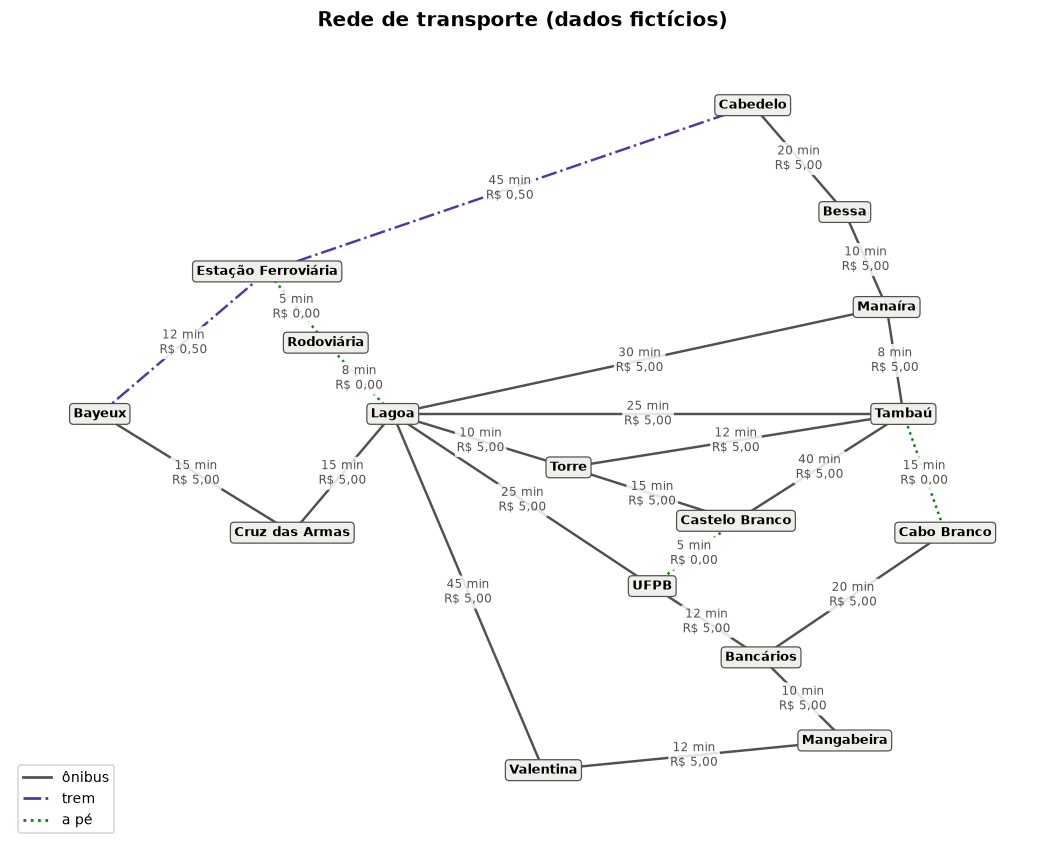

In [3]:
# Posições fixas que imitam o mapa: litoral a leste, Bayeux a oeste, Cabedelo ao norte
POSICOES = {
    "Cabedelo": (7.8, 10.2), "Bessa": (8.9, 8.4), "Manaíra": (9.4, 6.8), "Tambaú": (9.6, 5.0),
    "Cabo Branco": (10.1, 3.0), "Torre": (5.6, 4.1), "Castelo Branco": (7.6, 3.2), "UFPB": (6.6, 2.1),
    "Bancários": (7.9, 0.9), "Mangabeira": (8.9, -0.5), "Valentina": (5.3, -1.0), "Lagoa": (3.5, 5.0),
    "Rodoviária": (2.7, 6.2), "Estação Ferroviária": (2.0, 7.4), "Cruz das Armas": (2.3, 3.0), "Bayeux": (0.0, 5.0),
}
# Cor + tipo de linha por modo (a caminhada é pontilhada: não depende só da cor)
ESTILO_MODO = {"ônibus": ("#52514e", "solid"), "trem": ("#4a3aa7", "dashdot"), "a pé": ("#008300", "dotted")}

G = nx.Graph()   # cópia do grafo no networkx, apenas para desenhar
for a, b, tempo, tarifa, modo, linha in ARESTAS:
    G.add_edge(a, b, tempo=tempo, tarifa=tarifa, modo=modo)


def desenhar_grafo(ax, rotas=(), titulo="", rotulo=lambda d: f"{d['tempo']} min"):
    # 1) a rede, com cor e traço por modo
    for modo, (cor, estilo) in ESTILO_MODO.items():
        arestas = [(a, b) for a, b, d in G.edges(data=True) if d["modo"] == modo]
        nx.draw_networkx_edges(G, POSICOES, edgelist=arestas, ax=ax, edge_color=cor, style=estilo, width=1.6)
    # 2) rotas destacadas: a 1ª larga e translúcida, a 2ª fina por cima (trechos em comum continuam visíveis)
    for (caminho, cor, _), largura, alfa in zip(rotas, [13, 4.5], [0.5, 1.0]):
        nx.draw_networkx_edges(G, POSICOES, edgelist=list(zip(caminho, caminho[1:])), ax=ax,
                               edge_color=cor, width=largura, alpha=alfa)
    # 3) rótulos das arestas e das paradas
    nx.draw_networkx_edge_labels(G, POSICOES, edge_labels={(a, b): rotulo(d) for a, b, d in G.edges(data=True)},
                                 ax=ax, font_size=8, font_color=TINTA_SUAVE, rotate=False,
                                 bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.85})
    nx.draw_networkx_labels(G, POSICOES, ax=ax, font_size=8.5, font_weight="bold",
                            bbox={"boxstyle": "round,pad=0.3", "fc": "#f0efec", "ec": TINTA_SUAVE, "lw": 0.8})
    # 4) legenda: modos + rotas
    itens = [Line2D([], [], color=c, ls=e, lw=1.8, label=m) for m, (c, e) in ESTILO_MODO.items()]
    itens += [Line2D([], [], color=cor, lw=l * 0.6, alpha=a, label=nome)
              for (_, cor, nome), l, a in zip(rotas, [13, 4.5], [0.5, 1.0])]
    ax.legend(handles=itens, loc="lower left", fontsize=9)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.axis("off")
    ax.margins(0.05)


fig, ax = plt.subplots(figsize=(12, 9.5))
desenhar_grafo(ax, titulo="Rede de transporte (dados fictícios)",
               rotulo=lambda d: f"{d['tempo']} min\nR$ {d['tarifa']:.2f}".replace(".", ","))
plt.show()

## 2. Os dois algoritmos

| | **BFS**: busca em largura | **UCS**: busca de custo uniforme |
|---|---|---|
| **Ideia** | explora a rede em **camadas**: primeiro tudo a 1 trecho, depois a 2, … | explora sempre a parada com **menor custo acumulado** (aqui, menor tempo) |
| **Fronteira** | fila comum, FIFO (`deque`) | fila de prioridade (`heapq`) |
| **Quando para** | assim que **enxerga** o destino | quando o destino **sai** da fila, porque só então o custo é garantidamente o menor |
| **Encontra** | a rota com **menos trechos** | a rota com **menor custo**: tempo, tarifa, … |
| **Ignora** | tempo e tarifa | nada: usa o custo de cada trecho |

A diferença fica clara olhando **o que cada um "vê"** na mesma rede:

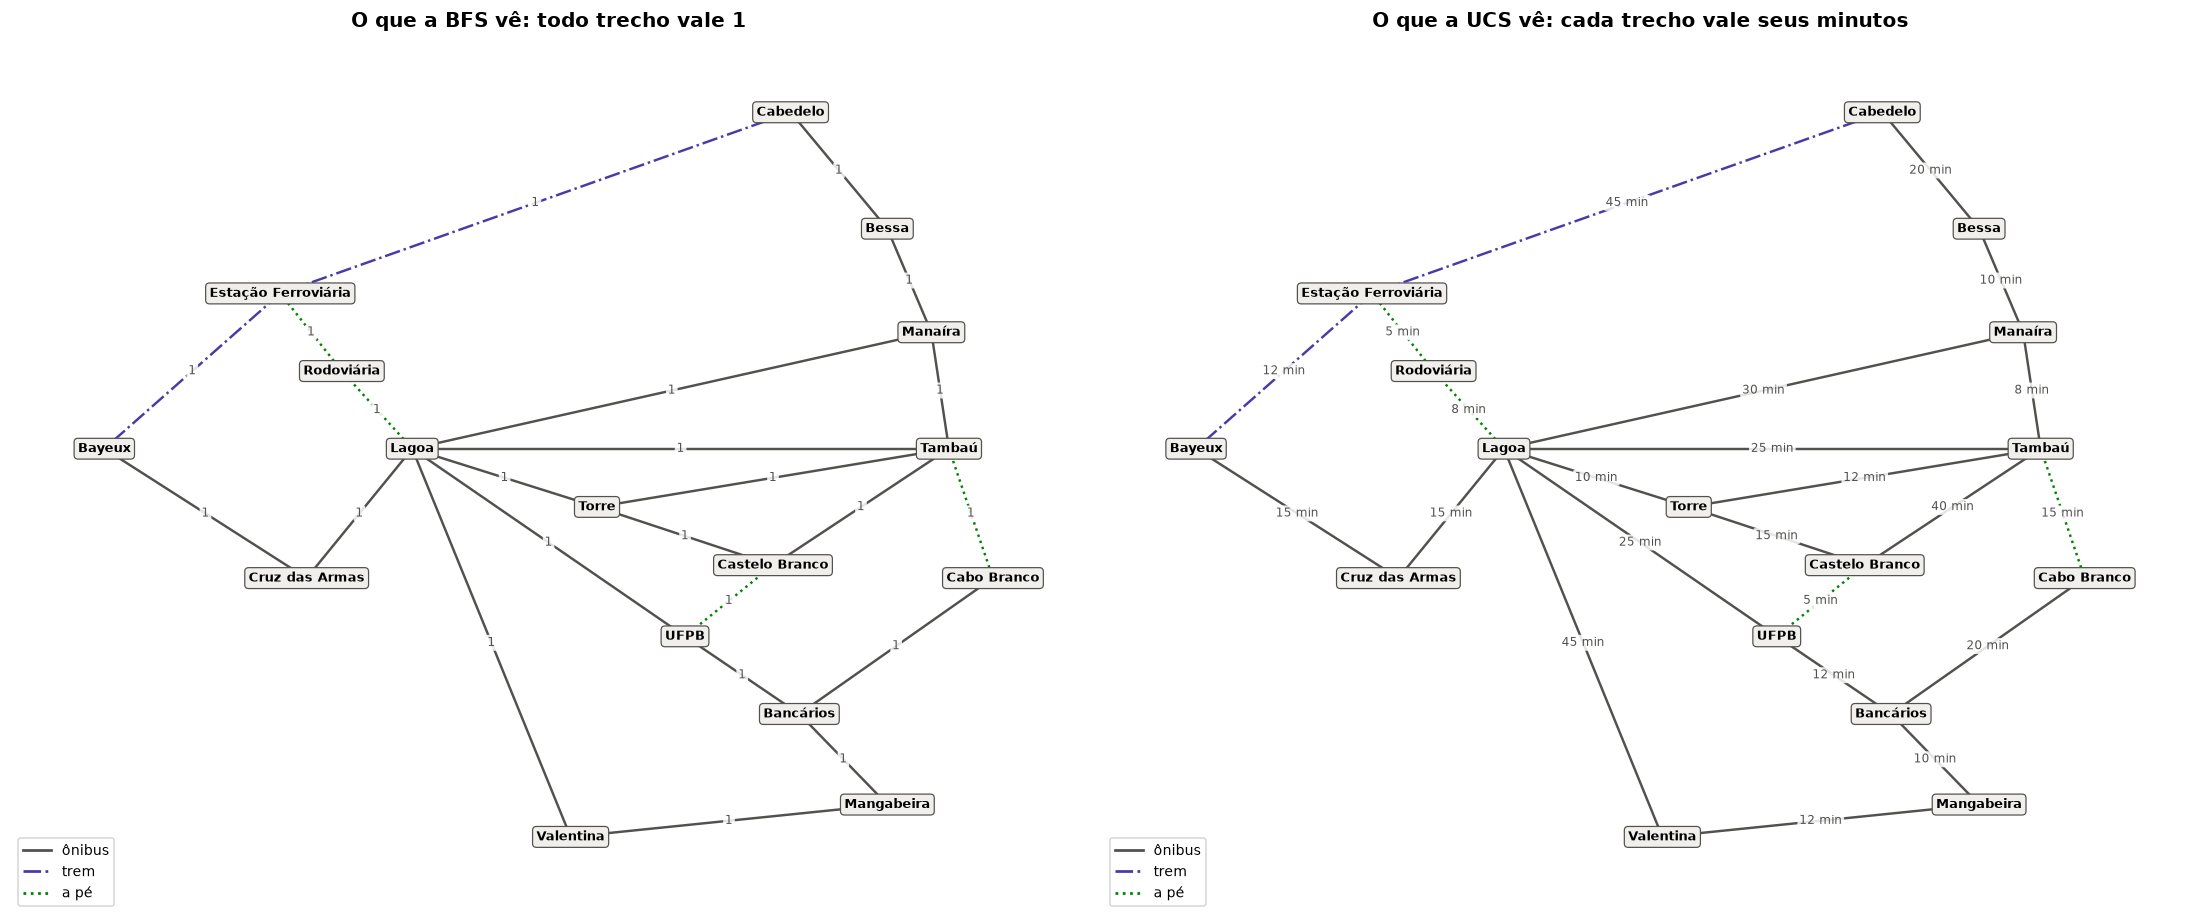

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8.5))
desenhar_grafo(ax1, titulo="O que a BFS vê: todo trecho vale 1", rotulo=lambda d: "1")
desenhar_grafo(ax2, titulo="O que a UCS vê: cada trecho vale seus minutos")
fig.tight_layout()
plt.show()

### Implementação

Os dois algoritmos são implementados do zero e têm quase o mesmo esqueleto. O que muda é **a estrutura da fronteira** e **o momento em que testamos o destino**.

In [5]:
@dataclass
class Resultado:
    algoritmo: str
    caminho: list      # paradas da origem ao destino
    arestas: list      # atributos de cada trecho percorrido
    expandidos: int    # quantas paradas o algoritmo precisou examinar (esforço)


def reconstruir(pai, destino):
    # Volta do destino até a origem seguindo o "pai" de cada parada, depois inverte
    caminho, arestas, no = [destino], [], destino
    while pai[no] is not None:
        no, atributos = pai[no]
        caminho.append(no)
        arestas.append(atributos)
    return caminho[::-1], arestas[::-1]


def bfs(grafo, origem, destino):
    fronteira = deque([origem])      # fila: quem entra primeiro sai primeiro
    pai = {origem: None}             # de onde viemos (e marca quem já foi alcançado)
    expandidos = 0
    while fronteira:
        no = fronteira.popleft()     # a parada mais antiga = a mais próxima em nº de trechos
        expandidos += 1
        for vizinho, atributos in grafo[no]:
            if vizinho in pai:       # já alcançado: não precisa de novo
                continue
            pai[vizinho] = (no, atributos)
            if vizinho == destino:   # para assim que ENXERGA o destino (vale porque todo trecho conta 1)
                return Resultado("BFS", *reconstruir(pai, destino), expandidos)
            fronteira.append(vizinho)
    return Resultado("BFS", [], [], expandidos)   # sem rota


def ucs(grafo, origem, destino, custo="tempo"):
    desempate = itertools.count()                  # em caso de empate no custo, sai quem entrou primeiro
    fronteira = [(0, next(desempate), origem)]     # heap de (custo acumulado, desempate, parada)
    melhor = {origem: 0}                           # menor custo conhecido até cada parada
    pai = {origem: None}
    expandidos = set()
    while fronteira:
        g, _, no = heapq.heappop(fronteira)       # a parada de MENOR custo acumulado
        if no in expandidos:                       # entrada antiga, já superada: ignora
            continue
        if no == destino:                          # só aqui o custo é garantidamente o menor
            return Resultado(f"UCS ({custo})", *reconstruir(pai, destino), len(expandidos))
        expandidos.add(no)
        for vizinho, atributos in grafo[no]:
            novo = g + atributos[custo]            # custo de chegar ao vizinho passando por `no`
            if novo < melhor.get(vizinho, float("inf")):   # achou um caminho mais barato?
                melhor[vizinho] = novo
                pai[vizinho] = (no, atributos)
                heapq.heappush(fronteira, (novo, next(desempate), vizinho))
    return Resultado(f"UCS ({custo})", [], [], len(expandidos))   # sem rota

## 3. Três percursos

Para cada percurso, rodamos os dois algoritmos e mostramos:

- o **mapa**: a rota da BFS em azul largo e a da UCS em laranja fino, por cima;
- o **itinerário**: cada bloco é um trecho, com comprimento igual ao tempo e cor igual ao modo.

In [6]:
def resumo(res):
    # Métricas da rota encontrada, calculadas somando os trechos
    tarifa = sum(a["tarifa"] for a in res.arestas)
    pagos = sum(1 for a in res.arestas if a["tarifa"] > 0)   # caminhada não é embarque
    return {"rota": " → ".join(res.caminho), "trechos": len(res.arestas),
            "tempo (min)": sum(a["tempo"] for a in res.arestas), "tarifa (R$)": round(tarifa, 2),
            "baldeações": max(pagos - 1, 0), "paradas examinadas": res.expandidos}


def reais(v):
    return f"R$ {v:.2f}".replace(".", ",")


def desenhar_itinerario(ax, resultados, cores):
    # Uma barra por algoritmo; cada bloco é um trecho (comprimento = minutos, cor = modo de transporte)
    for y, (res, cor) in enumerate(zip(resultados, cores)):
        y = len(resultados) - 1 - y            # primeiro algoritmo no topo
        t = 0
        for a, atr in zip(res.caminho, res.arestas):
            cor_modo, _ = ESTILO_MODO[atr["modo"]]
            a_pe = atr["modo"] == "a pé"
            ax.barh(y, atr["tempo"], left=t, height=0.45, color="#bfe0bf" if a_pe else cor_modo,
                    hatch="..." if a_pe else None, edgecolor=cor_modo if a_pe else "white", linewidth=1.2)
            if atr["tempo"] >= 6:              # escreve a linha dentro do bloco quando cabe
                ax.text(t + atr["tempo"] / 2, y, "a pé" if a_pe else atr["linha"], ha="center", va="center",
                        fontsize=8, fontweight="bold", color=TINTA if a_pe else "white")
            # nome da parada onde o trecho começa ("Estação Ferroviária" abreviado para caber)
            ax.text(t, y + 0.28, a.replace(" Ferroviária", ""), rotation=25, fontsize=7.5, color=TINTA_SUAVE,
                    va="bottom")
            t += atr["tempo"]
        ax.text(t, y + 0.28, res.caminho[-1], rotation=25, fontsize=7.5, fontweight="bold", va="bottom")
        r = resumo(res)
        ax.text(t + 1.5, y, f"{r['tempo (min)']} min · {reais(r['tarifa (R$)'])} · {r['trechos']} trechos",
                va="center", fontsize=9.5, fontweight="bold", color=TINTA)
        ax.scatter([-3], [y], s=90, marker="o" if res.algoritmo == "BFS" else "s", color=cor, clip_on=False)
    ax.set_yticks(range(len(resultados)), [r.algoritmo for r in reversed(resultados)], fontsize=10)
    ax.tick_params(axis="y", length=0, pad=18)
    ax.spines["left"].set_visible(False)
    ax.set_xlim(-5, max(sum(a["tempo"] for a in r.arestas) for r in resultados) + 40)
    ax.set_ylim(-0.5, len(resultados) - 0.1)
    ax.set_xlabel("minutos desde a partida")


def mostrar_percurso(origem, destino):
    r_bfs, r_ucs = bfs(grafo, origem, destino), ucs(grafo, origem, destino)
    fig, (ax_mapa, ax_it) = plt.subplots(2, 1, figsize=(12, 12.5), gridspec_kw={"height_ratios": [4.3, 1]})
    rb, ru = resumo(r_bfs), resumo(r_ucs)
    desenhar_grafo(ax_mapa, titulo=f"{origem} → {destino}",
                   rotas=[(r_bfs.caminho, COR_BFS, f"BFS: {rb['trechos']} trechos, {rb['tempo (min)']} min"),
                          (r_ucs.caminho, COR_UCS, f"UCS: {ru['trechos']} trechos, {ru['tempo (min)']} min")])
    desenhar_itinerario(ax_it, [r_bfs, r_ucs], [COR_BFS, COR_UCS])
    # legenda dos modos (no itinerário, a cor do bloco é o MODO, não o algoritmo)
    ax_it.legend(handles=[Patch(fc=ESTILO_MODO["ônibus"][0], label="ônibus"),
                          Patch(fc=ESTILO_MODO["trem"][0], label="trem"),
                          Patch(fc="#bfe0bf", ec=ESTILO_MODO["a pé"][0], hatch="...", label="a pé")],
                 loc="lower right", bbox_to_anchor=(1, 1.0), ncol=3, frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()
    return r_bfs, r_ucs


resultados = {}   # guarda os resultados dos 3 percursos para a comparação final

### Percurso 1: UFPB → Tambaú

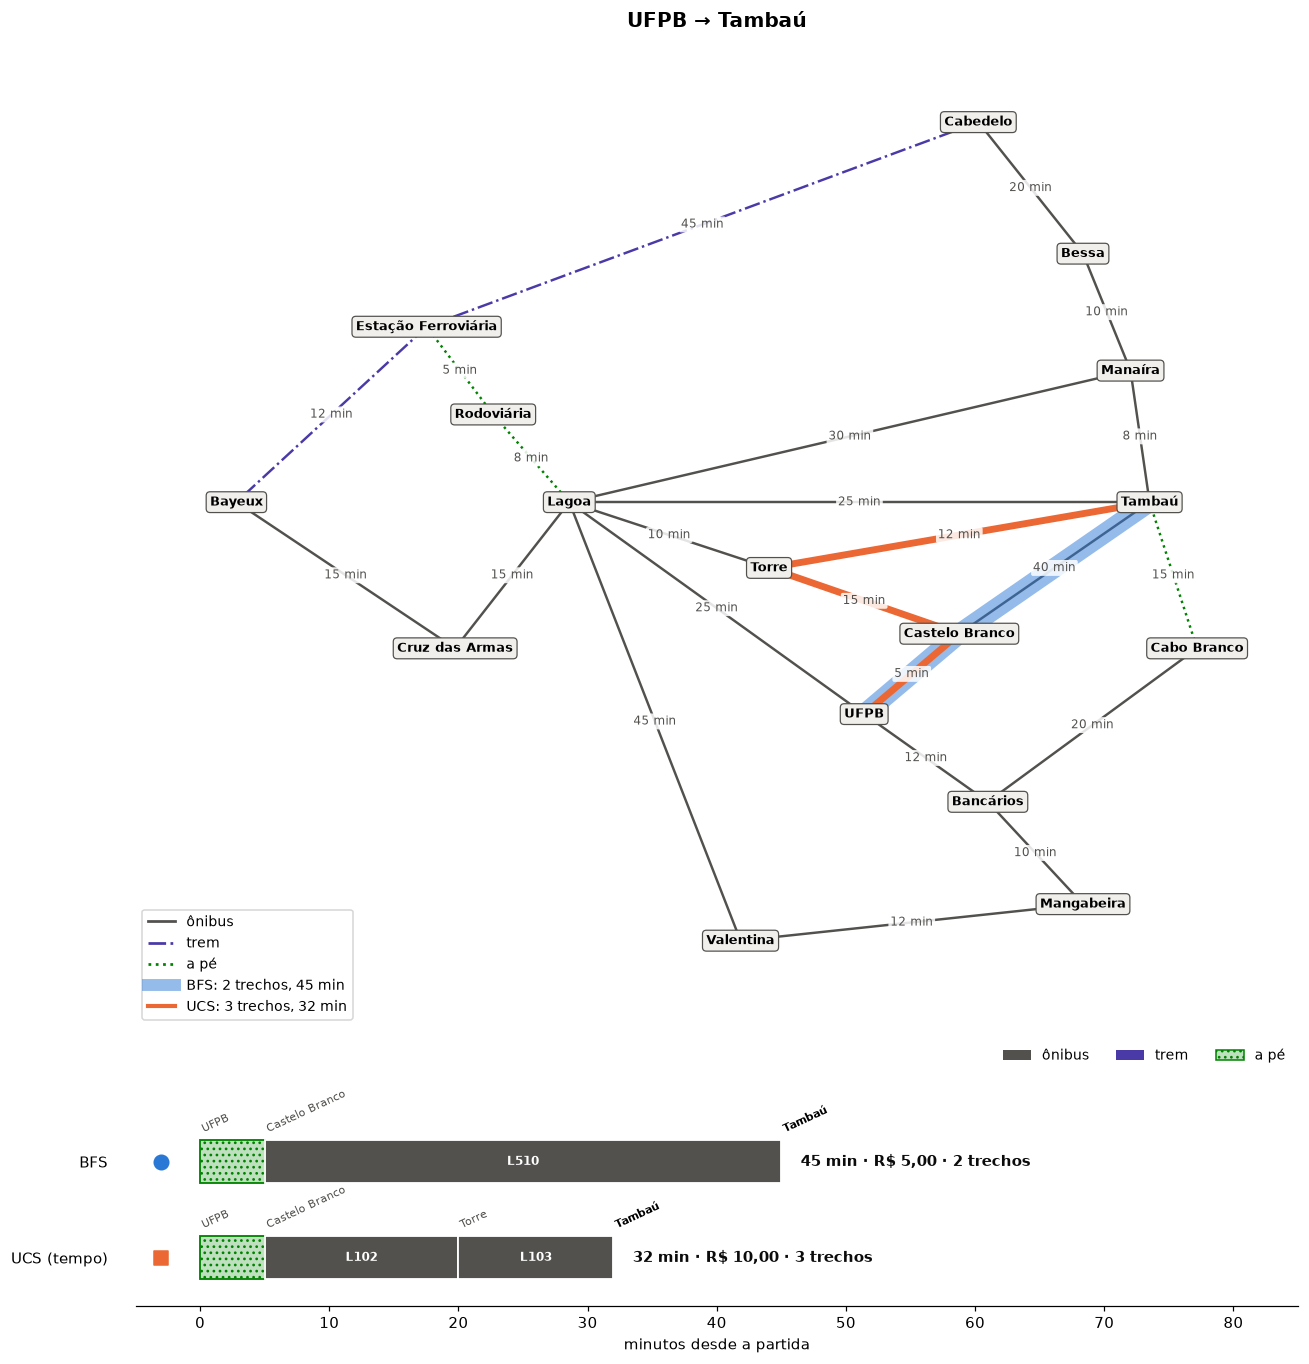

In [7]:
resultados["UFPB → Tambaú"] = mostrar_percurso("UFPB", "Tambaú")

# Confere os valores dos slides
r_bfs, r_ucs = (resumo(r) for r in resultados["UFPB → Tambaú"])
assert (r_bfs["trechos"], r_bfs["tempo (min)"]) == (2, 45)
assert (r_ucs["trechos"], r_ucs["tempo (min)"]) == (3, 32)

A **BFS** vai direto de Castelo Branco a Tambaú pela linha **L510**: são só 2 trechos, mas o ônibus leva **40 minutos**. A **UCS** faz uma baldeação na Torre (L102 + L103) e chega em **32 minutos**, 13 minutos mais rápido, com um trecho a mais.

### Percurso 2: Valentina → Bayeux

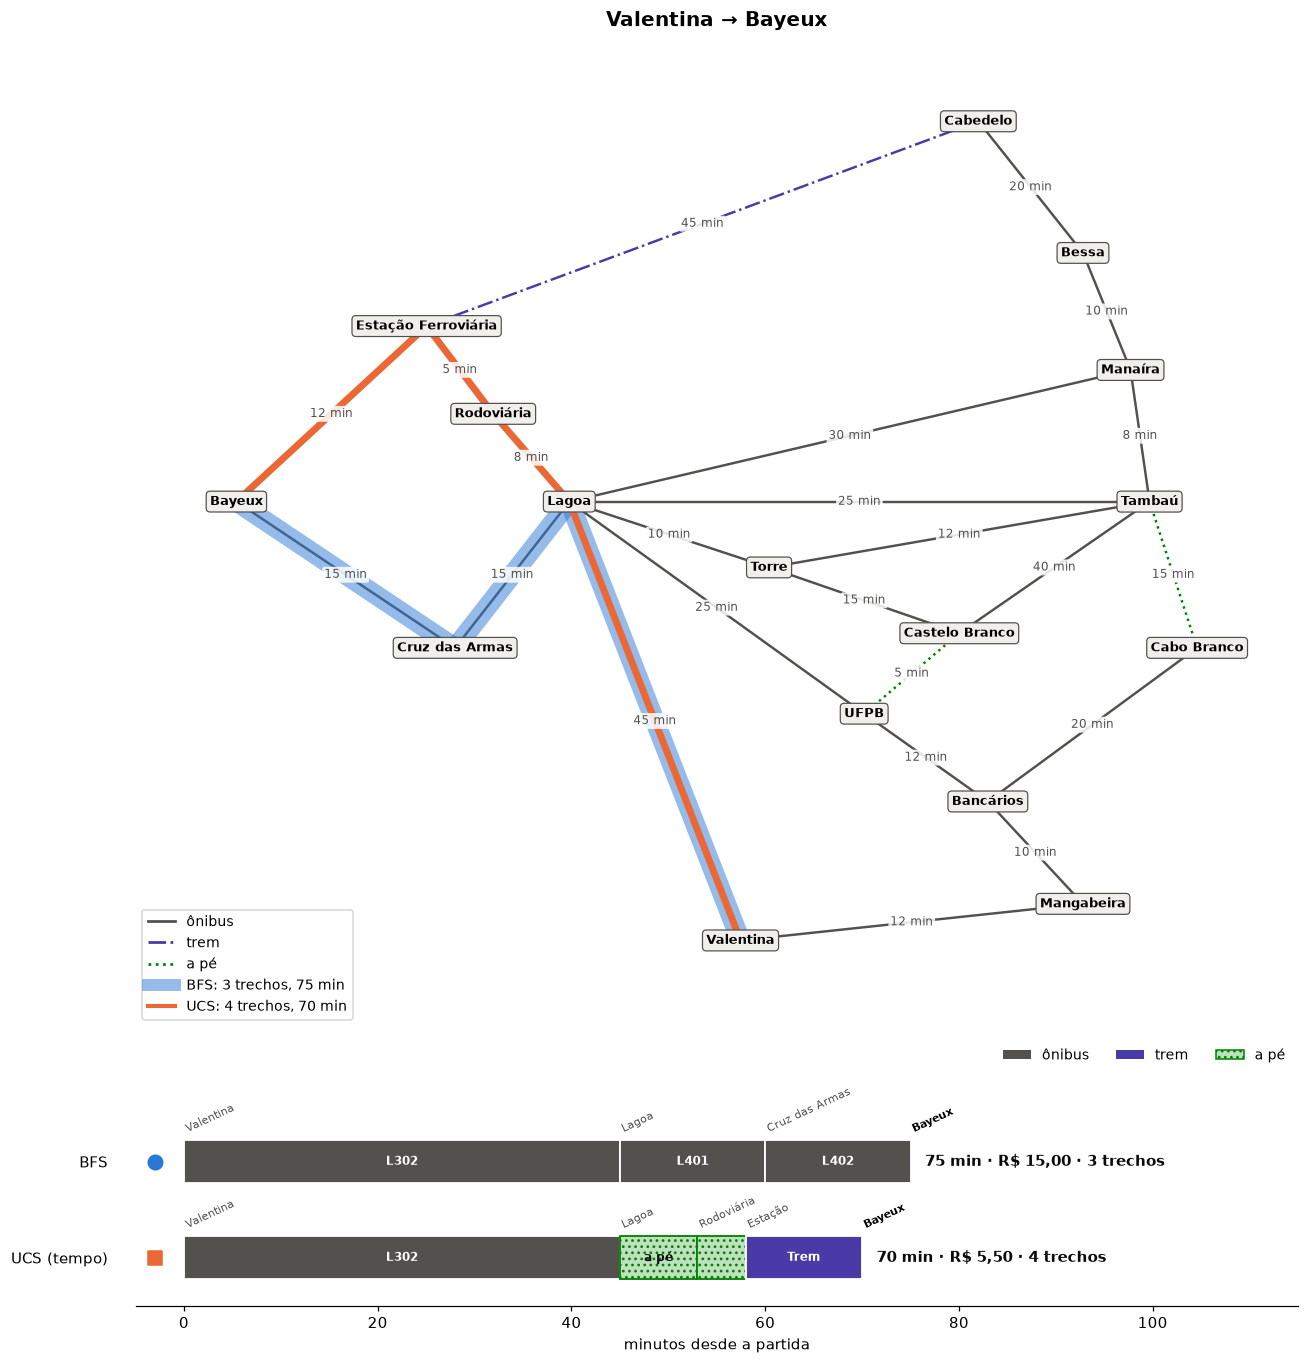

In [8]:
resultados["Valentina → Bayeux"] = mostrar_percurso("Valentina", "Bayeux")

Aqui a diferença é pequena, de **5 minutos**, mas as rotas são bem diferentes. A **BFS** usa três ônibus (R\$ 15,00). A **UCS** desce na Lagoa, caminha até a Estação e pega o **trem**: é mais rápida e ainda sai por **R\$ 5,50**. Menos trechos não significa nem mais rápido nem mais barato.

### Percurso 3: Mangabeira → Bessa

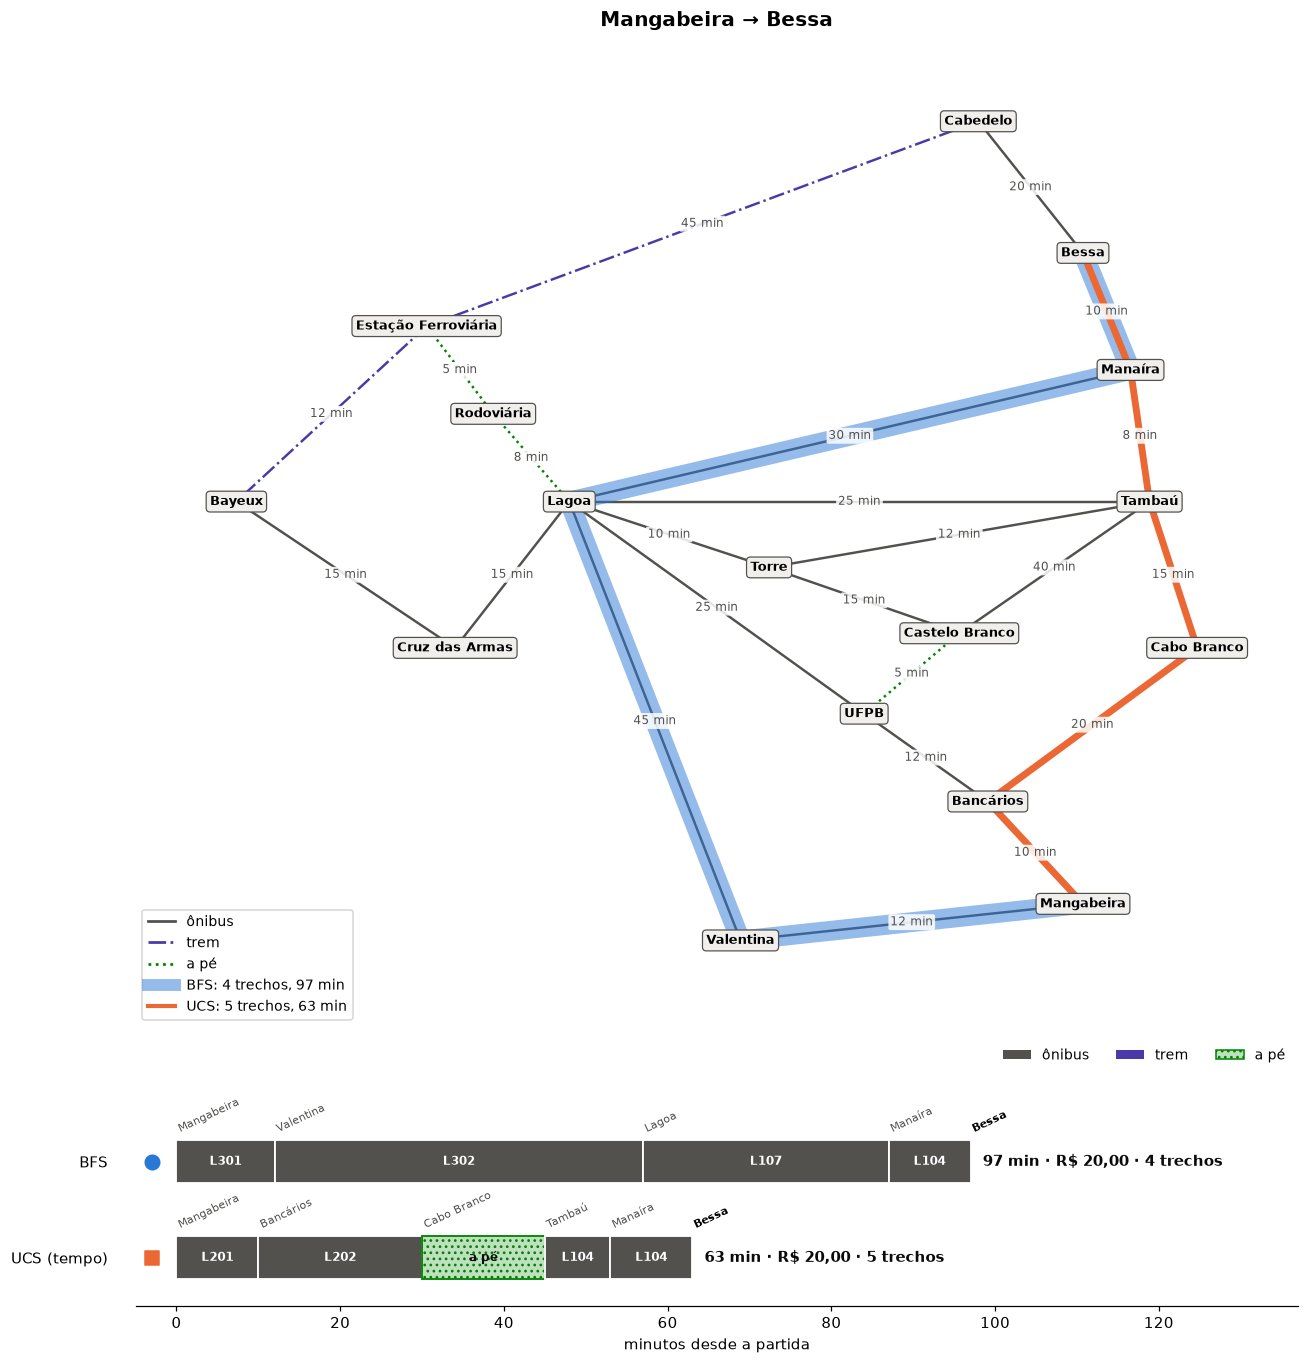

In [9]:
resultados["Mangabeira → Bessa"] = mostrar_percurso("Mangabeira", "Bessa")

É o caso mais extremo. A **BFS** passa pela Valentina e pega a linha L302, de **45 minutos**, e depois a L107, de 30 minutos, somando **97 minutos**. A **UCS** segue pelo litoral (Bancários → Cabo Branco → Tambaú) e chega em **63 minutos**: **34 minutos a menos**, com um trecho a mais.

## 4. Comparação dos resultados

In [10]:
linhas = []
for percurso, (r_bfs, r_ucs) in resultados.items():
    for res in (r_bfs, r_ucs):
        linhas.append({"percurso": percurso, "algoritmo": res.algoritmo, **resumo(res)})
tabela = pd.DataFrame(linhas).set_index(["percurso", "algoritmo"])
tabela[["trechos", "tempo (min)", "tarifa (R$)", "baldeações", "paradas examinadas"]]

trechos  tempo (min)  tarifa (R$)  baldeações  \
percurso           algoritmo                                                    
UFPB → Tambaú      BFS                2           45          5.0           0   
                   UCS (tempo)        3           32         10.0           1   
Valentina → Bayeux BFS                3           75         15.0           2   
                   UCS (tempo)        4           70          5.5           1   
Mangabeira → Bessa BFS                4           97         20.0           3   
                   UCS (tempo)        5           63         20.0           3   

                                paradas examinadas  
percurso           algoritmo                        
UFPB → Tambaú      BFS                           2  
                   UCS (tempo)                   7  
Valentina → Bayeux BFS                          10  
                   UCS (tempo)                  13  
Mangabeira → Bessa BFS                          10  
                   UCS (tempo)                  13

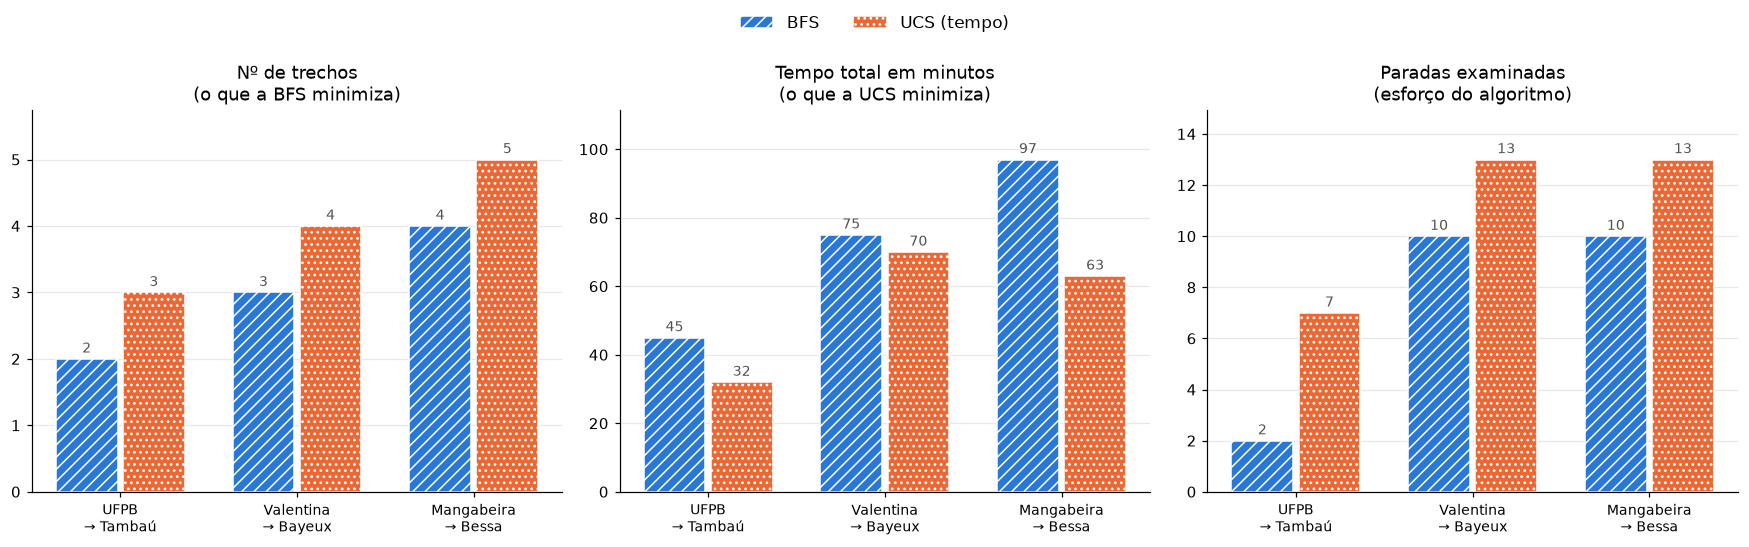

In [11]:
percursos = list(resultados)
metricas = [("trechos", "Nº de trechos\n(o que a BFS minimiza)"),
            ("tempo (min)", "Tempo total em minutos\n(o que a UCS minimiza)"),
            ("paradas examinadas", "Paradas examinadas\n(esforço do algoritmo)")]
largura = 0.38

fig, eixos = plt.subplots(1, 3, figsize=(16, 5))
for ax, (coluna, titulo) in zip(eixos, metricas):
    for i, (nome, cor, hachura) in enumerate([("BFS", COR_BFS, "///"), ("UCS (tempo)", COR_UCS, "...")]):
        valores = [tabela.loc[(p, nome), coluna] for p in percursos]
        xs = [x + (i - 0.5) * largura for x in range(len(percursos))]
        barras = ax.bar(xs, valores, width=largura * 0.92, color=cor, hatch=hachura, edgecolor="white",
                        label=nome.split(" ")[0])
        ax.bar_label(barras, padding=2, fontsize=9, color=TINTA_SUAVE)
    ax.set_xticks(range(len(percursos)), [p.replace(" → ", "\n→ ") for p in percursos], fontsize=9)
    ax.set_title(titulo, fontsize=11.5)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.margins(y=0.15)
fig.legend(handles=[Patch(fc=COR_BFS, hatch="///", ec="white", label="BFS"),
                    Patch(fc=COR_UCS, hatch="...", ec="white", label="UCS (tempo)")],
           loc="upper center", ncol=2, frameon=False, fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

In [12]:
# Quanto tempo a rota da BFS leva a mais em cada percurso
for percurso in percursos:
    t_bfs, t_ucs = tabela.loc[(percurso, "BFS"), "tempo (min)"], tabela.loc[(percurso, "UCS (tempo)"), "tempo (min)"]
    print(f"{percurso:<20} BFS {t_bfs} min × UCS {t_ucs} min → a BFS leva {t_bfs - t_ucs} min "
          f"({(t_bfs / t_ucs - 1):.0%}) a mais")

UFPB → Tambaú        BFS 45 min × UCS 32 min → a BFS leva 13 min (41%) a mais
Valentina → Bayeux   BFS 75 min × UCS 70 min → a BFS leva 5 min (7%) a mais
Mangabeira → Bessa   BFS 97 min × UCS 63 min → a BFS leva 34 min (54%) a mais


**Leitura dos gráficos:**

- **Nº de trechos:** a **BFS sempre vence**, porque é exatamente o que ela minimiza.
- **Tempo:** a **UCS sempre vence**, porque é exatamente o que ela minimiza. A rota da BFS levou de **7% a 54%** a mais.
- **Esforço:** a UCS examina um pouco mais de paradas, porque só para quando tem **certeza** de que não existe rota mais rápida. Nesta rede, isso leva microssegundos.

## 5. Conclusões

1. **Cada algoritmo responde a uma pergunta.** A BFS encontra a rota com **menos trechos**. A UCS encontra a rota de **menor custo**.
2. **Em transporte público, os trechos têm custos muito diferentes**: uma caminhada de 5 min, um ônibus de 40 min. Por isso, a rota com menos trechos muitas vezes **não** é a mais rápida.
3. **A UCS é flexível:** trocando o custo de `"tempo"` para `"tarifa"`, a mesma função passa a encontrar a rota mais barata.
4. **A BFS ainda tem seu lugar:** quando a pergunta é mesmo *"qual rota tem menos embarques?"*, ela é a escolha certa, e é mais simples e rápida.
5. **Próximo passo: A\***. É a UCS com uma "bússola", uma estimativa da distância até o destino, que evita explorar direções que se afastam dele.